<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Hands_on_Activity_6_1_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 6.1 Dimensionality Reduction

#### Objective:

This activity aims to perform reduction of dimensions using PCA

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to use pipelining for transformation and scaling.
* Deomnstrate how to perform principal component analysis to reduce dimension.


#### Resources:
* Jupyter Notebook
* Wholesale customers data.csv
* Human_Activity_Recognition_Using_Smartphones_Data.csv

#### Procedure:

Import the data and check the data types.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

file = '/content/Wholesale-customers-data.csv'
data = pd.read_csv(file)
data.shape


(440, 8)

In [ ]:
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
data.dtypes

,0
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicassen,int64


Drop the channel and region columns as they won't be used.

Copy this version of the data (using the `copy` method) to a variable to preserve it.

In [ ]:
data = data.drop(['Channel', 'Region'], axis=1)

In [ ]:
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


Convert the remaining columns to floats if necessary.

In [ ]:
for col in data.columns:
    data[col] = data[col].astype(float)

Preserve the original data.

In [ ]:
data_orig = data.copy()

Examine the correlation and skew.

In [ ]:
corr_mat = data.corr()

# Strip the diagonal for future examination
for x in range(corr_mat.shape[0]):
    corr_mat.iloc[x,x] = 0.0

corr_mat

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,0.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,0.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,0.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,0.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,0.000000,0.069291
Delicassen,0.244690,0.406368,0.205497,0.390947,0.069291,0.000000


In [ ]:
corr_mat.abs().idxmax()

,0
Fresh,Frozen
Milk,Grocery
Grocery,Detergents_Paper
Frozen,Delicassen
Detergents_Paper,Grocery
Delicassen,Milk


Interpret the result of the correlation

<font color = green>The sampled wholesale customer data depicts the correlation between certain product groups which aids us to detect the relation of purchases among the items transacted by the wholesale customers. The highlight of our analysis, however, is that the Fresh and Frozen products have a positive correlation of 34.5881%. Evidently, it means that the customers that overstock fresh commodities equally get hooked on frozen food. Milk and grocery can be also referred to as strong positively related products since it is rational that both of them are often bought together as everyday commodities.
The maximum positive correlation of 92.4641% is detected between Grocery and Detergent Paper products which shows the phenomenon that groceries customers also buy detergent and paper products that are generally needed in a household. Besides the already mentioned features, that is Frozen and Delicassen products manifest the correlation to a considerable extent, thus, the fact is that the customer who buys frozen products might be also the one buying some deli meats. Finally, there is a strong positive correlation between milk and Delicassen goods, which makes it those items are bought together slightly less than the others, but still, it is an extremely informative fact that will lead to certain business strategy changes.
Studying these interrelations will allow us to have a better understanding of the customer, thereby, we will be able to identify the items that are purchased together. These statistics also can be used as tools to establish probability and optimize stock levels in order to produce the necessary amount of related products; hence, lead suppliers to be more aware of the market demand. It is also used to convey the message that the customer correlates the products or to create the impression of an almost seamless customer experience.


Examine the skew values and log transform.

In [ ]:
log_columns = data.skew().sort_values(ascending=False)
log_columns = log_columns.loc[log_columns > 0.75]

log_columns

,0
Delicassen,11.151586
Frozen,5.907986
Milk,4.053755
Detergents_Paper,3.631851
Grocery,3.587429
Fresh,2.561323


In [ ]:
for col in log_columns.index:
    data[col] = np.log1p(data[col])

Interpret the result

<font color = green> Delicassen category is the one where the highest skewness in our data is seen, with a value of 11.15, which means that it is strongly positively skewed. Thus, most customers buy delicassen products of a small size, while several customers buy a very large number amount, which leads to skewness towards the right of the distribution. Frozen goods (5.91) also have a positive skew. This says most customers buy a little amount of frozen products, but a smaller set of customers buys a larger amount of frozen products at the same time.
Milk Detergents_Papers and Groceries also have a positive skewness, which is a similar trend showing that a few customers buy significantly more items than the average amount of these goods. Fresh products have a skewness of 2.56, which, although it is still positive, is the lowest compared to other categories. The latter reveals that fresh products’ purchase is fairly evenly distributed among the customers.
The log transformation method is the way, through which we hope to decrease skewness and ensure that our data is more suitable for further analysis.

Scale the data again

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

for col in data.columns:
    data[col] = mms.fit_transform(data[[col]]).squeeze()

Using Scikit-learn's pipeline function, recreate the data pre-processing scheme above (transformation and scaling) using a pipeline

In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# The custom NumPy log transformer
log_transformer = FunctionTransformer(np.log1p)

# The pipeline
estimators = [('log1p', log_transformer), ('minmaxscale', MinMaxScaler())]
pipeline = Pipeline(estimators)

# Convert the original data
data_pipe = pipeline.fit_transform(data_orig)

In [ ]:
np.allclose(data_pipe, data)

True

Perform PCA with n_components ranging from 1 to 5. Store the amount of explained variance for each number of dimensions.Also store the feature importance for each number of dimensions.

In [ ]:
from sklearn.decomposition import PCA

pca_list = list()
feature_weight_list = list()

# Fit a range of PCA models

for n in range(1, 6):

    # Create and fit the model
    PCAmod = PCA(n_components=n)
    PCAmod.fit(data)

    # Store the model and variance
    pca_list.append(pd.Series({'n':n, 'model':PCAmod,
                               'var': PCAmod.explained_variance_ratio_.sum()}))

    # Calculate and store feature importances
    abs_feature_values = np.abs(PCAmod.components_).sum(axis=0)
    feature_weight_list.append(pd.DataFrame({'n':n,
                                             'features': data.columns,
                                             'values':abs_feature_values/abs_feature_values.sum()}))

pca_df = pd.concat(pca_list, axis=1).T.set_index('n')
pca_df

,model,var
n,,
1,PCA(n_components=1),0.448011
2,PCA(n_components=2),0.72099
3,PCA(n_components=3),0.827534
4,PCA(n_components=4),0.923045
5,PCA(n_components=5),0.979574


Create a table of feature importances for each data column.

In [ ]:
features_df = (pd.concat(feature_weight_list)
               .pivot(index='n', columns='features', values='values'))

features_df

features,Delicassen,Detergents_Paper,Fresh,Frozen,Grocery,Milk
n,,,,,,
1,0.071668,0.335487,0.060620,0.095979,0.190236,0.246010
2,0.151237,0.177519,0.158168,0.222172,0.112032,0.178872
3,0.165518,0.145815,0.211434,0.268363,0.084903,0.123967
4,0.224259,0.149981,0.239527,0.214275,0.070971,0.100987
5,0.211840,0.182447,0.196382,0.178104,0.067338,0.163888


Create a plot of explained variances.

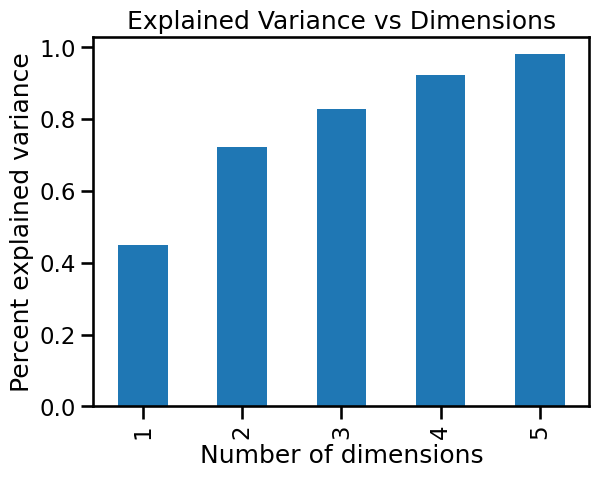

In [ ]:
sns.set_context('talk')

ax = pca_df['var'].plot(kind='bar')

ax.set(xlabel='Number of dimensions',
       ylabel='Percent explained variance',
       title='Explained Variance vs Dimensions');

And here's a plot of feature importances.

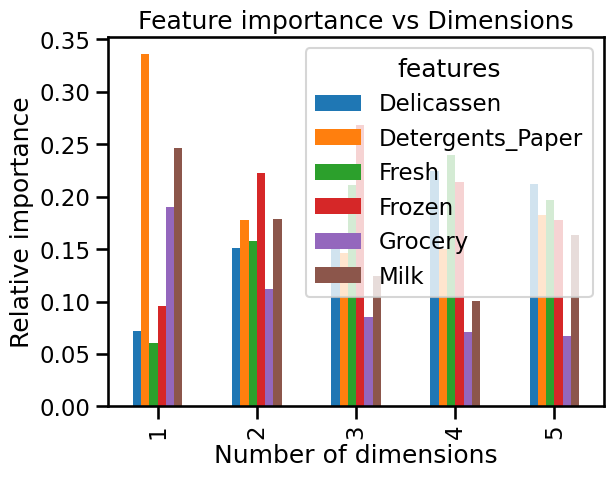

In [ ]:
ax = features_df.plot(kind='bar')

ax.set(xlabel='Number of dimensions',
       ylabel='Relative importance',
       title='Feature importance vs Dimensions');

Let us include the PCA in building the model using logistic regression and pipeline.

Load the dataset.

In [ ]:
filepath = '/content/Human_Activity_Recognition_Using_Smartphones_Data.csv'
df = pd.read_csv(filepath)

Create a pipeline, then predicts the "Activity" column over a 5-fold StratifiedShuffleSplit, and returns the average test accuracy

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


X = df.drop('Activity', axis=1)
y = df.Activity
sss = StratifiedShuffleSplit(n_splits=5, random_state=42)

def get_avg_score(n):
    pipe = [
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n)),
        ('estimator', LogisticRegression())
    ]
    pipe = Pipeline(pipe)
    scores = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]
        pipe.fit(X_train, y_train)
        scores.append(accuracy_score(y_test, pipe.predict(X_test)))
    return np.mean(scores)


ns = [10, 20, 50, 100, 150, 200, 300, 400]
score_list = [get_avg_score(n) for n in ns]

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Plot the average accuracy by number of dimensions.

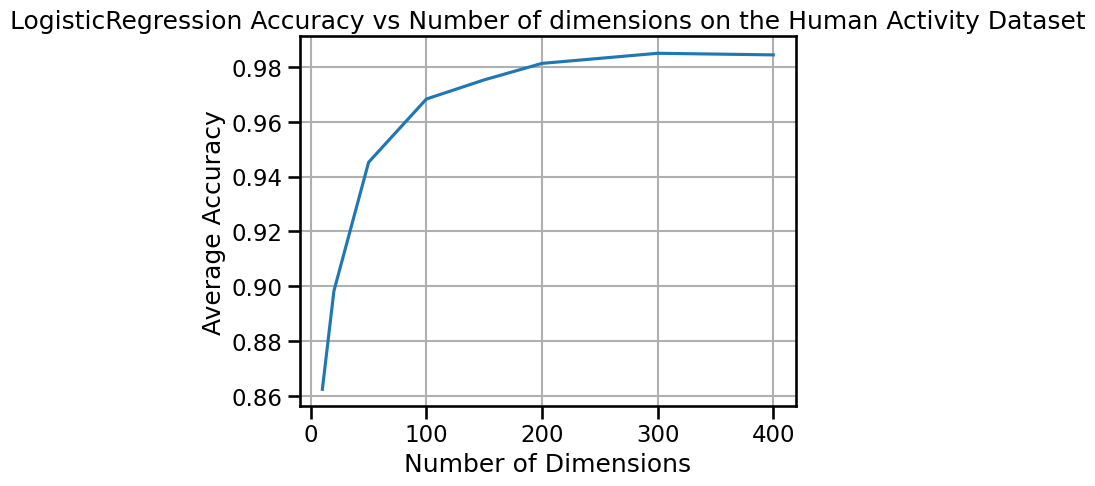

In [ ]:
sns.set_context('talk')

ax = plt.axes()
ax.plot(ns, score_list)
ax.set(xlabel='Number of Dimensions',
       ylabel='Average Accuracy',
       title='LogisticRegression Accuracy vs Number of dimensions on the Human Activity Dataset')
ax.grid(True)

Supplementary Activity:
* Choose your own dataset.
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Standardize the variables (if necessary).
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Use pipelining.
* Perform PCA
* Use logistic regression with PCA.
* Plot the average accuracy by number of dimensions.

##[College Dataset](https://www.kaggle.com/datasets/flyingwombat/us-news-and-world-reports-college-data)

#**About the Dataset:**
Statistics for a large number of US Colleges from the 1995 issue of US News and World Report

##**Content**
A data frame with 777 observations on the following 18 variables.

**Private** A factor with levels No and Yes indicating private or public university

**Apps** Number of applications received

**Accept** Number of applications accepted

**Enroll** Number of new students enrolled

**Top10perc Pct.** new students from top 10% of H.S. class

**Top25perc Pct.** new students from top 25% of H.S. class

**F.Undergrad** Number of fulltime undergraduates

**P.Undergrad** Number of parttime undergraduates

**Outstate** Out-of-state tuition

**Room.Board** Room and board costs

**Books** Estimated book costs

**Personal** Estimated personal spending

**PhD Pct.** of faculty with Ph.D.’s

**Terminal Pct.** of faculty with terminal degree

**S.F.Ratio** Student/faculty ratio

**perc.alumni** Pct. alumni who donate

**Expend** Instructional expenditure per student

**Grad.Rate** Graduation rate

### **Import the Dataset**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

file = '/content/College.csv'
college_df = pd.read_csv(file)


### **Determine the datapoints, columns, and dtypes**

In [ ]:
college_df.shape

(777, 19)

In [ ]:
college_df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [ ]:
college_df.dtypes

,0
Unnamed: 0,object
Private,object
Apps,int64
Accept,int64
Enroll,int64
Top10perc,int64
Top25perc,int64
F.Undergrad,int64
P.Undergrad,int64
Outstate,int64


### **Remove unnecessary columns**

We will remove all categorical data since we dont need it in performing this activity.

In [ ]:
#Remove unecessary columns
college_df = college_df.drop(['Unnamed: 0', 'Private'], axis=1)

### **Data Cleaning**

In [ ]:
# data cleaning such as removing empty values(NaN), replacing missing data .
college_df.isnull().sum()

,0
Apps,0
Accept,0
Enroll,0
Top10perc,0
Top25perc,0
F.Undergrad,0
P.Undergrad,0
Outstate,0
Room.Board,0
Books,0


We don't have  null values  does we will proceed in changing the changing the datatypes of each column to float

In [ ]:
#make all column as float
for col in college_df.columns:
    college_df[col] = college_df[col].astype(float)

Save the original dataset

In [ ]:
#save the original
college_df_orig = college_df.copy()

###**Standarizing the variables**

Before we standarize the data we need to examin the correlation and the skewedness of the data.

In [ ]:
#Examine the correlation and skew
corr_mat = college_df.corr()

# Strip the diagonal for future examination
for x in range(corr_mat.shape[0]):
    corr_mat.iloc[x,x] = 0.0

corr_mat



,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Apps,0.000000,0.943451,0.846822,0.338834,0.351640,0.814491,0.398264,0.050159,0.164939,0.132559,0.178731,0.390697,0.369491,0.095633,-0.090226,0.259592,0.146755
Accept,0.943451,0.000000,0.911637,0.192447,0.247476,0.874223,0.441271,-0.025755,0.090899,0.113525,0.200989,0.355758,0.337583,0.176229,-0.159990,0.124717,0.067313
Enroll,0.846822,0.911637,0.000000,0.181294,0.226745,0.964640,0.513069,-0.155477,-0.040232,0.112711,0.280929,0.331469,0.308274,0.237271,-0.180794,0.064169,-0.022341
Top10perc,0.338834,0.192447,0.181294,0.000000,0.891995,0.141289,-0.105356,0.562331,0.371480,0.118858,-0.093316,0.531828,0.491135,-0.384875,0.455485,0.660913,0.494989
Top25perc,0.351640,0.247476,0.226745,0.891995,0.000000,0.199445,-0.053577,0.489394,0.331490,0.115527,-0.080810,0.545862,0.524749,-0.294629,0.417864,0.527447,0.477281
F.Undergrad,0.814491,0.874223,0.964640,0.141289,0.199445,0.000000,0.570512,-0.215742,-0.068890,0.115550,0.317200,0.318337,0.300019,0.279703,-0.229462,0.018652,-0.078773
P.Undergrad,0.398264,0.441271,0.513069,-0.105356,-0.053577,0.570512,0.000000,-0.253512,-0.061326,0.081200,0.319882,0.149114,0.141904,0.232531,-0.280792,-0.083568,-0.257001
Outstate,0.050159,-0.025755,-0.155477,0.562331,0.489394,-0.215742,-0.253512,0.000000,0.654256,0.038855,-0.299087,0.382982,0.407983,-0.554821,0.566262,0.672779,0.571290
Room.Board,0.164939,0.090899,-0.040232,0.371480,0.331490,-0.068890,-0.061326,0.654256,0.000000,0.127963,-0.199428,0.329202,0.374540,-0.362628,0.272363,0.501739,0.424942
Books,0.132559,0.113525,0.112711,0.118858,0.115527,0.115550,0.081200,0.038855,0.127963,0.000000,0.179295,0.026906,0.099955,-0.031929,-0.040208,0.112409,0.001061


In [ ]:
corr_mat.abs().idxmax()

,0
Apps,Accept
Accept,Apps
Enroll,F.Undergrad
Top10perc,Top25perc
Top25perc,Top10perc
F.Undergrad,Enroll
P.Undergrad,F.Undergrad
Outstate,Expend
Room.Board,Outstate
Books,Personal


Perform log transform to lessen the skewedness of our data

In [ ]:
log_columns = college_df.skew().sort_values(ascending=False)
log_columns = log_columns.loc[log_columns > 0.75]

log_columns

,0
P.Undergrad,5.692353
Apps,3.723750
Books,3.485025
Expend,3.459322
Accept,3.417727
Enroll,2.690465
F.Undergrad,2.610458
Personal,1.742497
Top10perc,1.413217


In [ ]:
for col in log_columns.index:
    college_df[col] = np.log1p(college_df[col])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

for col in college_df.columns:
    college_df[col] = mms.fit_transform(college_df[[col]]).squeeze()

###**Perform descriptive statistics such as mean, median and mode**

In [ ]:
#Perform descriptive statistics such as mean, median and mode
college_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,0.473921,0.168298,0.0,0.352784,0.462030,0.594409,1.0
Accept,777.0,0.479022,0.167958,0.0,0.359163,0.462387,0.594956,1.0
Enroll,777.0,0.500557,0.183624,0.0,0.368677,0.481100,0.622114,1.0
Top10perc,777.0,0.637913,0.161728,0.0,0.535723,0.640182,0.744641,1.0
Top25perc,777.0,0.514249,0.217635,0.0,0.351648,0.494505,0.659341,1.0
F.Undergrad,777.0,0.497041,0.189413,0.0,0.361411,0.461463,0.618726,1.0
P.Undergrad,777.0,0.539224,0.172846,0.0,0.416338,0.556682,0.664868,1.0
Outstate,777.0,0.418423,0.207800,0.0,0.257231,0.395145,0.546746,1.0
Room.Board,777.0,0.406294,0.172871,0.0,0.286412,0.381463,0.515448,1.0
Books,777.0,0.533732,0.084877,0.0,0.496336,0.515732,0.572896,1.0


### **Data Visualization**

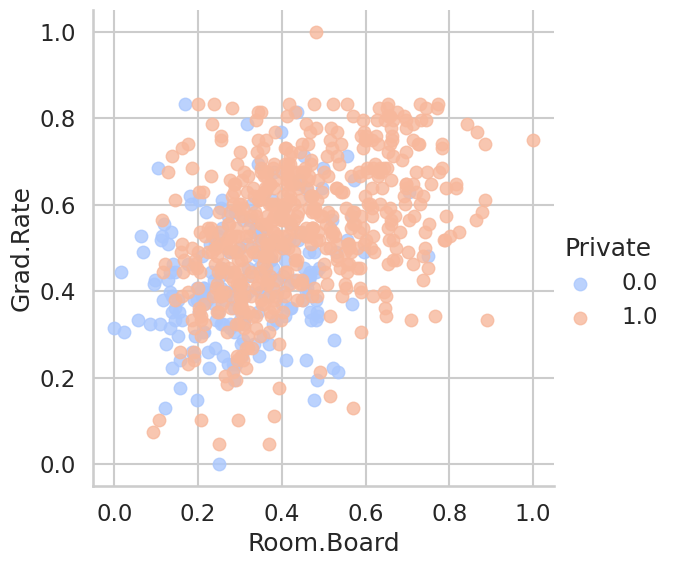

In [ ]:

sns.set_style('whitegrid')
sns.lmplot(x='Room.Board',y='Grad.Rate',data=college_df, hue='Private',
           palette='coolwarm',height=6,aspect=1,fit_reg=False)

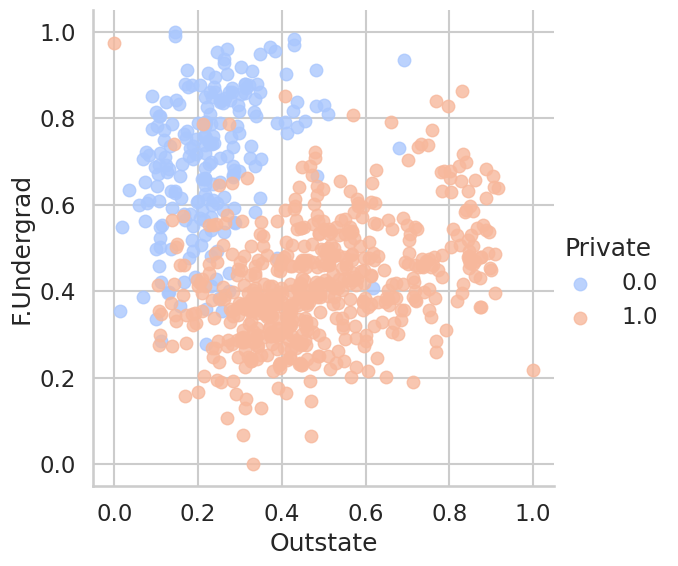

In [ ]:
sns.set_style('whitegrid')
sns.lmplot(x='Outstate',y='F.Undergrad',data=college_df, hue='Private',
           palette='coolwarm',height=6,aspect=1,fit_reg=False)

###**Use pipelining**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

In [ ]:
X = college_df_orig.drop('Private', axis=1)
y = college_df_orig['Private']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [ ]:
steps = [('scaler', StandardScaler()),
         ('pca', PCA(n_components=.95)),
         ('clf', LogisticRegression())]
pipe_lr = Pipeline(steps)

pipe_lr.fit(X_train, y_train)
train_predictions = pipe_lr.predict(X_train)
test_predictions = pipe_lr.predict(X_test)

print("TRAIN:")
print(classification_report(y_train, train_predictions))

print("TEST:")
print(classification_report(y_test, test_predictions))

TRAIN:
              precision    recall  f1-score   support

          No       0.92      0.88      0.90       177
         Yes       0.96      0.97      0.96       483

    accuracy                           0.95       660
   macro avg       0.94      0.92      0.93       660
weighted avg       0.94      0.95      0.95       660

TEST:
              precision    recall  f1-score   support

          No       0.81      0.86      0.83        35
         Yes       0.94      0.91      0.93        82

    accuracy                           0.90       117
   macro avg       0.87      0.89      0.88       117
weighted avg       0.90      0.90      0.90       117



<font color = green> The model perform very well on training set with high precision score, recall and F1 score mostly in "Yes" Class. The test result  are slightly lower but still indicate a  strong performance with an over all accuracy of 90%. The precision and recall for "No" class are lower on test  set compared to training  suggest that the model might be slightly overfitting  and may hardly predict that the student is enrolled in public. Our F1 score indicate a good balance  between precision and recall which suggest that  our model is effective at both identifying positive instances and minimizing false positive.

In [ ]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.pipeline import Pipeline

# Selecting only the numerical columns for transformation
college_df_orig_num = college_df_orig.select_dtypes(include=[np.number])

# Define the pipeline
log_transformer = FunctionTransformer(np.log1p)
estimators = [
    ('log1p', log_transformer),
    ('minmaxscale', MinMaxScaler())
]
pipeline = Pipeline(estimators)

# Apply the pipeline
data_pipe = pipeline.fit_transform(college_df_orig_num)

# Convert the transformed data back to a DataFrame for comparison and clarity
transformed_df = pd.DataFrame(data_pipe, columns=college_df_orig_num.columns)

# Output the first few rows of the transformed data
transformed_df.head()


,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,0.471973,0.480082,0.578925,0.640182,0.721159,0.558232,0.601697,0.519327,0.406551,0.482707,0.658069,0.844019,0.824048,0.690953,0.614449,0.276199,0.719368
1,0.515133,0.555740,0.512943,0.551341,0.475068,0.544845,0.690455,0.744337,0.847994,0.642882,0.542053,0.491987,0.154064,0.540512,0.678714,0.416298,0.690885
2,0.448371,0.460388,0.431816,0.629217,0.704526,0.369410,0.420728,0.704999,0.490751,0.445797,0.465507,0.732177,0.706049,0.561552,0.822633,0.351295,0.675886
3,0.255524,0.266213,0.259436,0.880503,0.950137,0.238850,0.372731,0.768539,0.737018,0.482707,0.378834,0.954318,0.978404,0.370761,0.871406,0.622292,0.712426
4,0.135097,0.118880,0.085305,0.551341,0.650402,0.106965,0.653389,0.526511,0.552732,0.663128,0.542053,0.877170,0.767476,0.531151,0.263179,0.429129,0.157353


In [ ]:
np.allclose(data_pipe, transformed_df)

True

### Perform PCA

In [ ]:
from sklearn.decomposition import PCA

pca_list = list()
feature_weight_list = list()

# Fit a range of PCA models

for n in range(1, 6):

    # Create and fit the model
    PCAmod = PCA(n_components=n)
    PCAmod.fit(transformed_df)

    # Store the model and variance
    pca_list.append(pd.Series({'n':n, 'model':PCAmod,
                               'var': PCAmod.explained_variance_ratio_.sum()}))

    # Calculate and store feature importances
    abs_feature_values = np.abs(PCAmod.components_).sum(axis=0)
    feature_weight_list.append(pd.DataFrame({'n':n,
                                             'features': transformed_df.columns,
                                             'values':abs_feature_values/abs_feature_values.sum()}))

pca_df = pd.concat(pca_list, axis=1).T.set_index('n')
pca_df

,model,var
n,,
1,PCA(n_components=1),0.360048
2,PCA(n_components=2),0.651411
3,PCA(n_components=3),0.724746
4,PCA(n_components=4),0.775981
5,PCA(n_components=5),0.818619


<font color= green>However, the model is not very accurate when using only one component; that means it doesn't capture the variance of data by any single part. As the number of components increases, the precision is improved. This begins to capture more of the variance in data using two components, which improves the accuracy of predictions made by the model. The accuracy of the model with five components reaches approximately 0.82, suggesting that the addition of more components is expected to improve it somewhat. However, the improvement in accuracy is not as rapid as it seems initially. The rate of improvement decreases as more components are added. By reducing the number of components to 5 or less, it is possible to achieve a good balance between performance and complexity.

In [ ]:
features_df = (pd.concat(feature_weight_list)
               .pivot(index='n', columns='features', values='values'))

features_df

features,Accept,Apps,Books,Enroll,Expend,F.Undergrad,Grad.Rate,Outstate,P.Undergrad,Personal,PhD,Room.Board,S.F.Ratio,Terminal,Top10perc,Top25perc,perc.alumni
n,,,,,,,,,,,,,,,,,
1,0.128432,0.129906,0.012842,0.137919,0.036841,0.138960,0.023472,0.015274,0.057769,0.026046,0.053538,0.031442,0.005980,0.071536,0.060721,0.069109,0.000215
2,0.072113,0.067767,0.007111,0.087836,0.063162,0.094477,0.042081,0.073184,0.072444,0.037710,0.041068,0.058357,0.033668,0.058011,0.074177,0.074675,0.042159
3,0.059440,0.055626,0.007820,0.064715,0.057978,0.066990,0.030480,0.086334,0.082552,0.035881,0.038187,0.103014,0.032155,0.042623,0.094468,0.097268,0.044468
4,0.058353,0.052922,0.018628,0.059340,0.060003,0.056099,0.040030,0.066277,0.082807,0.085025,0.029373,0.088496,0.041384,0.034067,0.086962,0.087554,0.052677
5,0.056838,0.052894,0.019701,0.057780,0.055747,0.050137,0.041471,0.063700,0.080275,0.080676,0.053269,0.076673,0.043294,0.071252,0.072978,0.072362,0.050951


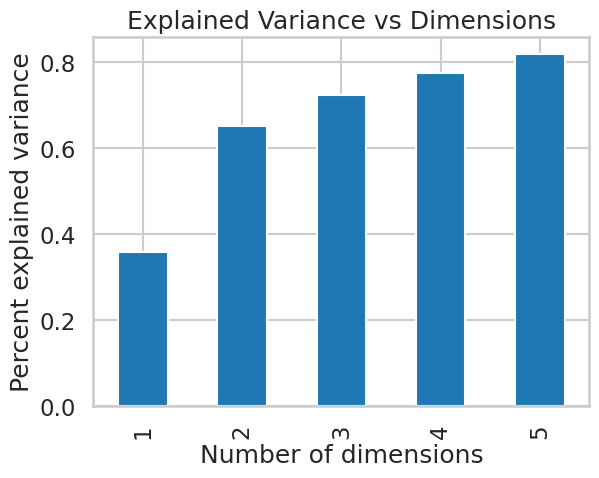

In [ ]:
sns.set_context('talk')

ax = pca_df['var'].plot(kind='bar')

ax.set(xlabel='Number of dimensions',
       ylabel='Percent explained variance',
       title='Explained Variance vs Dimensions');

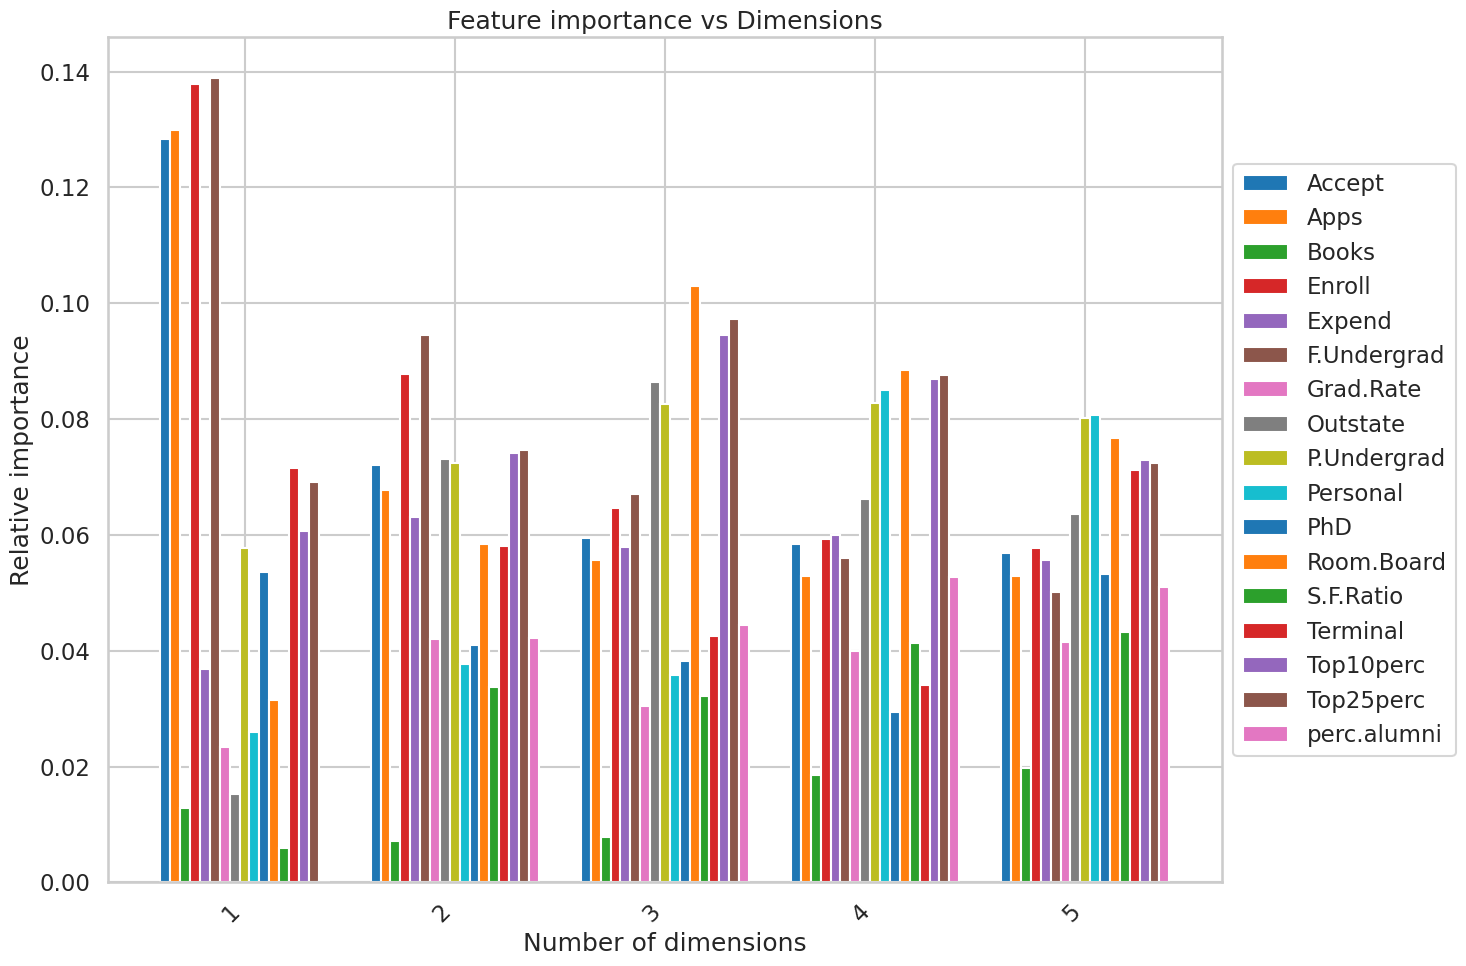

In [ ]:
# Create the bar plot
ax = features_df.plot(kind='bar', figsize=(15, 10), width=0.8)

# Set labels and title
ax.set(xlabel='Number of dimensions',
       ylabel='Relative importance',
       title='Feature importance vs Dimensions')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Move legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))  # Position the legend outside the plot

# Adjust layout to ensure everything fits
plt.tight_layout()




###**Use logistic regression with PCA.**


In [ ]:
#Load again the dataset
file = '/content/College.csv'
college_df = pd.read_csv(file)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, f1_score

In [ ]:
#remove unnecessary column
college_df = college_df.drop(['Unnamed: 0'], axis=1)

In [ ]:
X = college_df.drop('Private', axis=1)
y = college_df['Private']
sss = StratifiedShuffleSplit(n_splits=5, random_state=42)

In [ ]:
# Assuming get_avg_score function is defined as in your previous input
def get_avg_score(n):
    scores = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]

        # Determine the maximum allowable n_components
        max_components = min(X_train.shape[0], X_train.shape[1])

        # Adjust n_components if it exceeds the maximum
        n_components = min(n, max_components)

        pipe = Pipeline([('scaler', StandardScaler()),
                         ('pca', PCA(n_components=n_components, svd_solver='covariance_eigh')), # Limit n_components
                         ('logistic', LogisticRegression(max_iter=10000))])
        pipe.fit(X_train, y_train)
        scores.append(accuracy_score(y_test, pipe.predict(X_test)))
    return np.mean(scores)

# Example usage
ns = [10, 20, 50, 100, 150, 200, 300, 400]
score_list = [get_avg_score(n) for n in ns]

###**Plot the average accuracy by number of dimensions.**

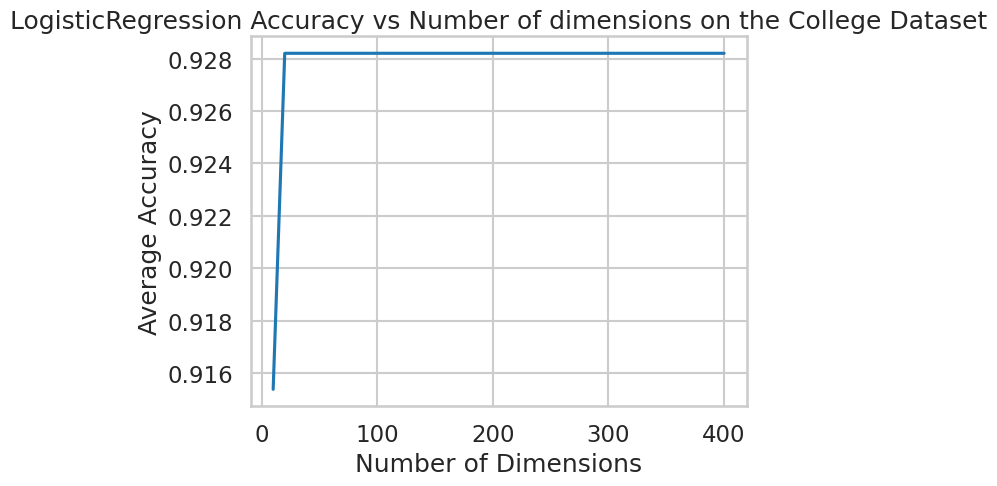

In [ ]:
sns.set_context('talk')

ax = plt.axes()
ax.plot(ns, score_list)
ax.set(xlabel='Number of Dimensions',
       ylabel='Average Accuracy',
       title='LogisticRegression Accuracy vs Number of dimensions on the College Dataset')
ax.grid(True)

<font color = green> Based on the graph above, our accuracy rapidly increases as more dimension were included in the model. After a numerous dimension it stabilizes in 92.8% accuracy indicating that adding more dimension in this point  does not significantly improved our accuracy.

## **Conclusion**

<font color = green>The application of dimensionality reduction techniques, particularly Principal Component Analysis (PCA), was the focus of this acitivity. We utilized these techniques to analyze real-world datasets, such as Wholesale Customers and Human Activity Recognition. Additionally, We preprocessed the data to ensure it was PCA-compliant by implementing steps such as log transformation for accuracy and scale. By using pipelines, these crucial steps of data preparation were simplified.

<font color = green>While preserving valuable information, PCA managed to reduce the number of dimensions in our datasets. The number of principal components that are ideal for each situation was determined by examining explained variance and feature importance plots. The outcomes indicated that PCA's modeling approach can be both straightforward and accurate. However, this was not always the case. The use of PCA in a logistic regression pipeline resulted in comparable or better performance with fewer dimensions, as seen in the Human Activity Recognition dataset.

<font color = green>The implementation of dimensionality reduction and PCA in real-life scenarios was demonstrated through these activities. We were able to use these techniques to study customer purchasing patterns and identify human activities.'... Moreover, our investigations also covered the US College dataset, which provided more information on managing skewness and displaying how PCA affects model performance. We discovered that PCAA could reduce the size of the college data without significantly altering its accuracy in a logistic regression model for determining whether he was referring to public or private colleges. Specifically, the model's accuracy reached a plateau after varying numbers of dimensions, suggesting that the returns from increasing the number of principal components would be less than diminishing. On the whole, however, this work demonstrated how dimensionality reduction techniques such as PCA can be used to reduce complexity of data, extract deeper meanings, and construct more efficient and interpretable machine learning models.